## Ejercicio Práctico 1: Análisis de estrategias de opciones con datos reales

1. Usando yfinance, descarga la cadena de opciones vigente de un activo de tu elección con opciones líquidas.

2. Selecciona los contratos necesarios para construir dos de las siguientes estrategias (cada estudiante elige cuáles):
- Long straddle

- Bull call spread

- Bear put spread

- Iron condor

- Protective put

3. Para cada estrategia: grafica el diagrama de payoff al vencimiento, e indica claramente el breakeven, la ganancia máxima y la pérdida máxima.

4. Reporta las Griegas individuales de cada contrato usado (Delta, Gamma, Theta, Vega) tomándolas de la cadena de opciones o calculándolas con Black-Scholes. Calcula las Griegas netas del portafolio resultante de cada estrategia.

5. En markdown: explica en qué condición de mercado (dirección esperada y nivel de volatilidad) tiene sentido cada estrategia construida. Vincula explícitamente tu respuesta con el signo e interpretación de al menos dos Griegas netas calculadas.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime


In [2]:

# Funciones de Black-Scholes para calcular Griegas 
def bs_greeks(S, K, T, r, sigma, option_type='call'):
    """Calcula las Griegas de una opción usando Black-Scholes"""
    if T <= 0 or sigma <= 0:
        return {'delta': 0, 'gamma': 0, 'theta': 0, 'vega': 0}
        
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100 # Dividido por 100 para impacto de 1%
    
    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        
    return {'delta': delta, 'gamma': gamma, 'theta': theta, 'vega': vega}

# Función de Grafica
def plot_payoff(ST, payoff, title, breakevens, max_profit, max_loss):
    plt.figure(figsize=(10, 6))
    plt.plot(ST, payoff, color='blue', linewidth=2, label='Payoff al Vencimiento')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Sombreado de ganancias y pérdidas
    plt.fill_between(ST, payoff, 0, where=(payoff >= 0), facecolor='green', alpha=0.2, label='Ganancia')
    plt.fill_between(ST, payoff, 0, where=(payoff < 0), facecolor='red', alpha=0.2, label='Pérdida')
    
    # Anotaciones
    for be in breakevens:
        plt.axvline(be, color='orange', linestyle=':', linewidth=2)
        plt.text(be, max(payoff)*0.5, f' BE: {be:.2f}', color='orange', rotation=90)
        
    plt.title(title, fontsize=14)
    plt.xlabel('Precio del Subyacente al Vencimiento ($S_T$)', fontsize=12)
    plt.ylabel('Pérdida / Ganancia', fontsize=12)
    
    # Text box con métricas
    textstr = f'Max Profit: {max_profit}\nMax Loss: {max_loss}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
            
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

Subyacente: SPY | Precio Actual (S0): $738.18 | Vencimiento: 2026-05-15

--- LONG STRADDLE ---
Strike ATM: $738.0
Griegas Call: {'delta': np.float64(1.0), 'gamma': np.float64(0.0), 'theta': np.float64(-0.09096386915717197), 'vega': np.float64(0.0)}
Griegas Put:  {'delta': np.float64(-9.351852625627544e-12), 'gamma': np.float64(1.1898511685650755e-09), 'theta': np.float64(-1.3328671246483444e-14), 'vega': np.float64(3.50489181710119e-11)}
GRIEGAS NETAS: {'delta': np.float64(0.9999999999906481), 'gamma': np.float64(1.1898511685650755e-09), 'theta': np.float64(-0.0909638691571853), 'vega': np.float64(3.50489181710119e-11)}


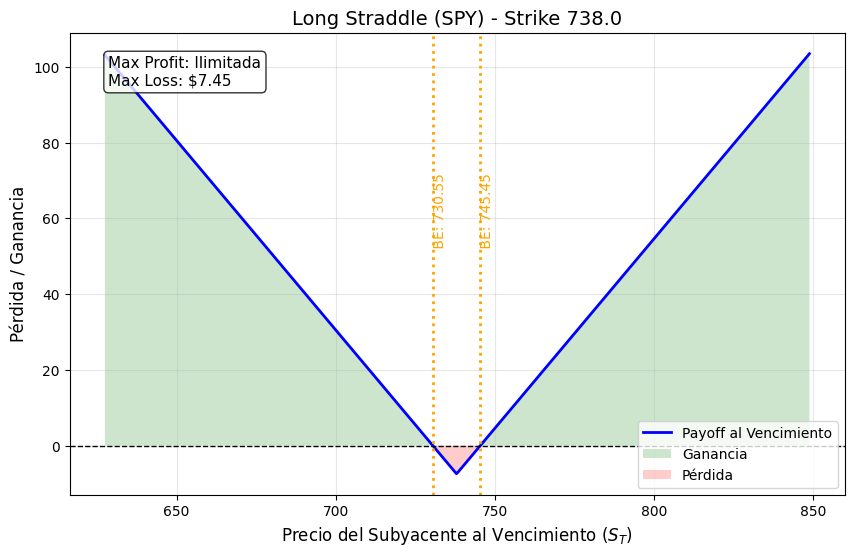

In [3]:

#  Descarga de Datos (SPY) 
ticker = 'SPY'
spy = yf.Ticker(ticker)
S0 = spy.history(period="1d")['Close'].iloc[0]

# Seleccionamos un vencimiento a ~30-45 días
expirations = spy.options
expiration_date = expirations[2] # Ajusta el índice si es necesario
opt_chain = spy.option_chain(expiration_date)

calls = opt_chain.calls
puts = opt_chain.puts

# Tasa libre de riesgo y tiempo al vencimiento
r = 0.045 # Asumiendo 4.5%
T = (datetime.strptime(expiration_date, '%Y-%m-%d') - datetime.now()).days / 365.0

print(f"Subyacente: {ticker} | Precio Actual (S0): ${S0:.2f} | Vencimiento: {expiration_date}")

#  ESTRATEGIA 1: LONG STRADDLE 
# Buscamos el strike ATM 
atm_strike = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]['strike'].values[0]

call_atm = calls[calls['strike'] == atm_strike].iloc[0]
put_atm = puts[puts['strike'] == atm_strike].iloc[0]

# Costo de las primas
C_atm = call_atm['lastPrice']
P_atm = put_atm['lastPrice']
costo_straddle = C_atm + P_atm

# Griegas Individuales y del Portafolio
greeks_c_atm = bs_greeks(S0, atm_strike, T, r, call_atm['impliedVolatility'], 'call')
greeks_p_atm = bs_greeks(S0, atm_strike, T, r, put_atm['impliedVolatility'], 'put')

net_greeks_straddle = {k: greeks_c_atm[k] + greeks_p_atm[k] for k in greeks_c_atm}

print("\n--- LONG STRADDLE ---")
print(f"Strike ATM: ${atm_strike}")
print(f"Griegas Call: {greeks_c_atm}")
print(f"Griegas Put:  {greeks_p_atm}")
print(f"GRIEGAS NETAS: {net_greeks_straddle}")

# Payoff
ST = np.linspace(S0 * 0.85, S0 * 1.15, 500)
payoff_call = np.maximum(ST - atm_strike, 0) - C_atm
payoff_put = np.maximum(atm_strike - ST, 0) - P_atm
payoff_straddle = payoff_call + payoff_put

be_straddle_1 = atm_strike - costo_straddle
be_straddle_2 = atm_strike + costo_straddle

plot_payoff(ST, payoff_straddle, f'Long Straddle ({ticker}) - Strike {atm_strike}', 
            [be_straddle_1, be_straddle_2], "Ilimitada", f"${costo_straddle:.2f}")



--- BULL CALL SPREAD ---
Compra Call Strike: $738.0 | Vende Call Strike: $760.0
Griegas Call Long:  {'delta': np.float64(1.0), 'gamma': np.float64(0.0), 'theta': np.float64(-0.09096386915717197), 'vega': np.float64(0.0)}
Griegas Call Short: {'delta': np.float64(2.1877343704608246e-10), 'gamma': np.float64(4.0946651687050297e-10), 'theta': np.float64(-1.2141877891356083e-09), 'vega': np.float64(7.64232006367557e-10)}
GRIEGAS NETAS: {'delta': np.float64(0.9999999997812266), 'gamma': np.float64(-4.0946651687050297e-10), 'theta': np.float64(-0.09096386794298418), 'vega': np.float64(-7.64232006367557e-10)}


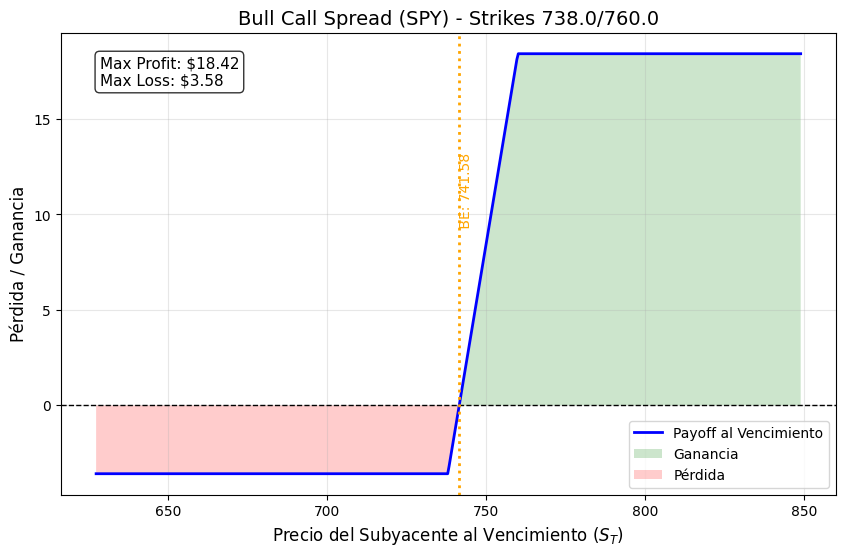

In [4]:

# ESTRATEGIA 2: BULL CALL SPREAD
# Buscamos un strike ITM/ATM para comprar, y uno OTM para vender
strike_low = atm_strike
strike_high = calls.iloc[(calls['strike'] - (S0 * 1.03)).abs().argsort()[:1]]['strike'].values[0] # ~3% OTM

call_low = calls[calls['strike'] == strike_low].iloc[0]
call_high = calls[calls['strike'] == strike_high].iloc[0]

C_low = call_low['lastPrice']
C_high = call_high['lastPrice']
costo_spread = C_low - C_high # Débito neto

# Griegas Individuales y del Portafolio (Se resta la opción vendida)
greeks_c_low = bs_greeks(S0, strike_low, T, r, call_low['impliedVolatility'], 'call')
greeks_c_high = bs_greeks(S0, strike_high, T, r, call_high['impliedVolatility'], 'call')

net_greeks_spread = {k: greeks_c_low[k] - greeks_c_high[k] for k in greeks_c_low}

print("\n--- BULL CALL SPREAD ---")
print(f"Compra Call Strike: ${strike_low} | Vende Call Strike: ${strike_high}")
print(f"Griegas Call Long:  {greeks_c_low}")
print(f"Griegas Call Short: {greeks_c_high}")
print(f"GRIEGAS NETAS: {net_greeks_spread}")

# Payoff
payoff_call_low = np.maximum(ST - strike_low, 0) - C_low
payoff_call_high = -(np.maximum(ST - strike_high, 0) - C_high)
payoff_spread = payoff_call_low + payoff_call_high

be_spread = strike_low + costo_spread
max_profit_spread = (strike_high - strike_low) - costo_spread

plot_payoff(ST, payoff_spread, f'Bull Call Spread ({ticker}) - Strikes {strike_low}/{strike_high}', 
            [be_spread], f"${max_profit_spread:.2f}", f"${costo_spread:.2f}")

### Análisis de las Estrategias y sus Griegas

**Nota importante sobre los datos:** El código eligió un "Strike" ($738) que ya está muy por debajo del precio actual del mercado (está profundamente *In-The-Money*). Por esta razón, los números salieron extremos: la opción Call se comporta exactamente como si hubiéramos comprado la acción normal (Delta = 1) y ya no le afectan ni el paso del tiempo ni el nerviosismo del mercado (Gamma y Vega = 0). A continuación, el análisis basado en estos números:

#### 1. Bull Call Spread (Strike Comprado: $738 | Strike Vendido: $760)
Esta es una apuesta 100% a que el precio de la acción va a subir. 
* **Griegas:**
    * **Delta ($\Delta$) de 1.0:** Nos confirma que somos "alcistas". Al ser 1, significa que por cada dólar que suba la acción, nuestra estrategia ganará exactamente un dólar. Es prácticamente como ser dueños de la acción.
    * **Vega ($\nu$) de 0.0:** Nos dice que a nuestra estrategia ya no le importa si el mercado se pone muy volátil o muy tranquilo. Las opciones están tan "adentro" o "afuera" del dinero que la volatilidad del mercado ya no cambia su precio.

#### 2. Long Straddle (Strike: $738)
Normalmente, un Straddle se usa cuando esperas un movimiento brusco, sin importar si es para arriba o para abajo. Sin embargo, por el Strike tan bajo que nos dio el código, esta estrategia terminó convirtiéndose en una simple apuesta a que el precio va a subir.
* **Griegas:**
    * **Delta ($\Delta$) de 1.0:** En un Straddle normal, la Delta debería ser cero (porque te da igual si sube o baja). Aquí es 1 porque la opción Call está haciendo todo el trabajo, mientras que la opción Put quedó de adorno (está tan lejos del precio que no aporta nada).
    * **Gamma ($\Gamma$) de 0.0:** El "súper-poder" de un Straddle normal es su Gamma positiva, la cual hace que tus ganancias se aceleren muchísimo si hay un salto brusco en el precio. Como aquí tenemos Gamma 0, perdemos ese efecto explosivo y la estrategia crece de forma aburrida y en línea recta.